# BTC Implied Volatility Surface
### End-to-end options analytics pipeline using live Deribit market data

1. **Fetch** live options data from Deribit (strikes, maturities, mark prices, spot)
2. **Extract the implied forward** per expiry using put-call parity
3. **Compute implied volatility** by inverting the Black-Scholes formula
4. **Filter** the data to keep only liquid, well-behaved options
5. **Fit the SVI parametric model** to each expiry slice
6. **Check and enforce arbitrage constraints** (calendar + butterfly)
7. **Build a smooth volatility surface** and compute option Greeks

---


In [1]:
import numpy as np
import pandas as pd
import requests, time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq, minimize

plt.style.use("seaborn-v0_8")

In [2]:
# Instruments
inst = pd.DataFrame(
    requests.get("https://www.deribit.com/api/v2/public/get_instruments",
                 params={"currency": "BTC", "kind": "option", "expired": "false"}).json()["result"]
)[["instrument_name", "strike", "option_type", "expiration_timestamp"]]

now_ms = int(time.time() * 1000)
inst["T"] = (inst["expiration_timestamp"] - now_ms) / (1000 * 60 * 60 * 24 * 365)
inst = inst[inst["T"] > 7 / 365].reset_index(drop=True)

# Mark prices
prices = pd.DataFrame(
    requests.get("https://www.deribit.com/api/v2/public/get_book_summary_by_currency",
                 params={"currency": "BTC", "kind": "option"}).json()["result"]
)[["instrument_name", "mark_price"]]

# Spot
spot = requests.get("https://www.deribit.com/api/v2/public/ticker",
                    params={"instrument_name": "BTC-PERPETUAL"}).json()["result"]["last_price"]
print(f"Spot: ${spot:,.0f}")

df = inst.merge(prices, on="instrument_name", how="inner").dropna()
df["spot"]  = spot
df["price"] = df["mark_price"] * spot
print(f"Options loaded: {len(df)}")


Spot: $70,850
Options loaded: 600


In [ ]:
# implied forward F = K + (C - P)

forwards = {}
for T_val, grp in df.groupby("T"):
    calls = grp[grp["option_type"] == "call"].set_index("strike")["price"]
    puts  = grp[grp["option_type"] == "put" ].set_index("strike")["price"]
    common = calls.index.intersection(puts.index)
    if len(common) == 0:
        forwards[T_val] = spot
        continue
    diff = (calls[common] - puts[common]).abs()
    K_star = diff.idxmin()
    C_star = calls[K_star]
    P_star = puts[K_star]
    forwards[T_val] = K_star + (C_star - P_star)  # put-call parity: F = K + C - P

df["F"] = df["T"].map(forwards)
print("Implied forwards (first 5 expiries):")
for T, F in sorted(forwards.items())[:5]:
    print(f"  T={T:.4f}y  F=${F:,.0f}  (spot=${spot:,.0f}  diff={F-spot:+.0f})")


Implied forwards (first 5 expiries):
  T=0.0234y  F=$70,854  (spot=$70,850  diff=+4)
  T=0.0426y  F=$70,877  (spot=$70,850  diff=+27)
  T=0.0810y  F=$70,919  (spot=$70,850  diff=+69)
  T=0.1769y  F=$71,086  (spot=$70,850  diff=+236)
  T=0.2536y  F=$71,226  (spot=$70,850  diff=+376)


## Black-Scholes IV Inversion & Filtering

### The Black-Scholes Formula (forward form)

With $r = 0$ and using the implied forward $F$, the Black-Scholes call price is:

$$C = F \cdot N(d_1) - K \cdot N(d_2)$$

$$d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and the put price by put-call parity:

$$P = K \cdot N(-d_2) - F \cdot N(-d_1)$$

where $N(\cdot)$ is the standard normal CDF.

### Implied Volatility

The **implied volatility** $\hat{\sigma}$ is the unique $\sigma$ that solves:

$$\text{BS}(F, K, T, \hat{\sigma}) = \text{Market Price}$$

### Data Filtering


| Filter | Reason |
|--------|--------|
| OTM only: calls with $K \geq F$, puts with $K \leq F$ | ITM options have wide spreads and redundant info (put-call parity links them to OTM) |
| $\|k\| \leq 1.0$ | Deep OTM options ($k > 1$ means strike is $e \approx 2.7\times$ the forward) have near-zero prices and unreliable IVs |
| $0.05 < \hat{\sigma} < 2.0$ | Sanity bounds: IV below 5% or above 200% is a data artifact |
| Price $> \$5$ | Very cheap options are effectively bid at zero — their IV is meaningless |

### Log-Moneyness and Total Variance

We define two key quantities used throughout:

$$k = \ln\left(\frac{K}{F}\right) \qquad \text{(log-moneyness)}$$

$$w = \hat{\sigma}^2 \cdot T \qquad \text{(total implied variance)}$$

$w$ is the natural variable for SVI and arbitrage theory because it is additive in time.


In [4]:
def bs_price(F, K, T, sigma, flag="call"):
    """Black-Scholes with forward price (r=0 discounting already in F)."""
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if flag == "call":
        return F * norm.cdf(d1) - K * norm.cdf(d2)
    else:
        return K * norm.cdf(-d2) - F * norm.cdf(-d1)

def implied_vol(price, F, K, T, flag="call"):
    try:
        return brentq(lambda s: bs_price(F, K, T, s, flag) - price, 1e-4, 10.0, xtol=1e-8)
    except Exception:
        return np.nan

df["iv"] = df.apply(
    lambda r: implied_vol(r["price"], r["F"], r["strike"], r["T"], r["option_type"]), axis=1
)
df = df.dropna(subset=["iv"])

# OTM only (relative to implied forward)
otm = ((df["option_type"] == "call") & (df["strike"] >= df["F"])) |       ((df["option_type"] == "put")  & (df["strike"] <= df["F"]))
df = df[otm].copy()

# Log-moneyness vs implied forward
df["k"] = np.log(df["strike"] / df["F"])

# Sensible bounds
df = df[df["k"].abs() <= 1.0]
df = df[(df["iv"] > 0.05) & (df["iv"] < 2.0)]
df = df[df["price"] > 5.0]

df["w"] = df["iv"]**2 * df["T"]

print(f"Options after filtering: {len(df)}")
print(f"Expiries: {df['T'].nunique()}")


Options after filtering: 273
Expiries: 7


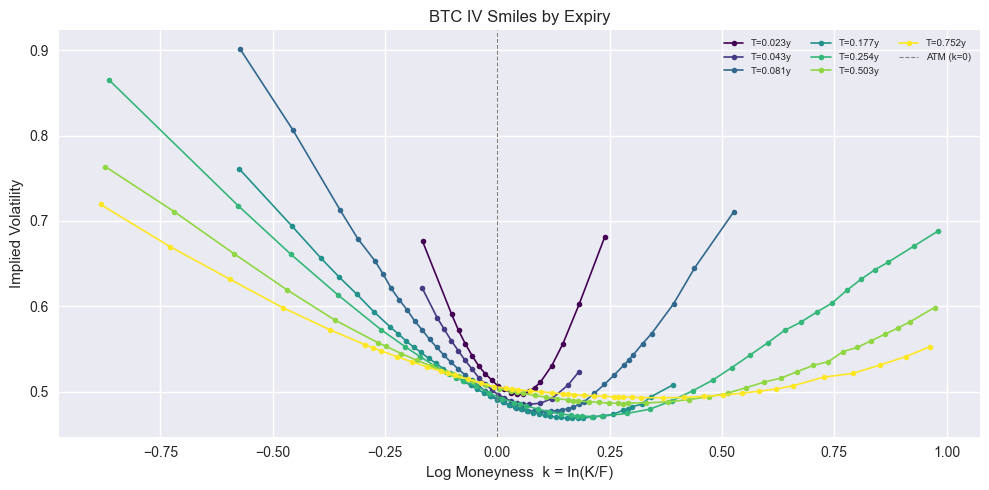

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
expiries = sorted(df["T"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(expiries)))

for color, T_val in zip(colors, expiries):
    sl = df[df["T"] == T_val].sort_values("k")
    ax.plot(sl["k"], sl["iv"], marker="o", ms=4, lw=1.2, color=color,
            label=f"T={T_val:.3f}y")

ax.axvline(0, color="grey", lw=0.8, ls="--", label="ATM (k=0)")
ax.set_xlabel("Log Moneyness  k = ln(K/F)")
ax.set_ylabel("Implied Volatility")
ax.set_title("BTC IV Smiles by Expiry")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()


## SVI Model Calibration

$$w(k) = a + b\left[\rho(k - m) + \sqrt{(k-m)^2 + \sigma^2}\right]$$

The five parameters have intuitive interpretations:

| Parameter | Role |
|-----------|------|
| $a$ | Overall level of variance (vertical shift) |
| $b \geq 0$ | Angle between the left and right asymptotes (controls wing steepness) |
| $\rho \in (-1, 1)$ | Skew — rotates the smile left/right, controls put/call asymmetry |
| $m$ | Horizontal shift — moves the minimum away from ATM |
| $\sigma > 0$ | Smoothness at the ATM vertex — controls curvature at the bottom |

The implied volatility is recovered as:

$$\hat{\sigma}(k, T) = \sqrt{\frac{w(k)}{T}}$$

In [6]:
def svi(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def fit_svi(k, w, T_val):
    bounds = [(-0.5, 1.0), (1e-4, 2.0), (-0.999, 0.999), (-1.5, 1.5), (1e-4, 2.0)]
    w_atm  = float(w[np.argmin(np.abs(k))])

    seeds = [
        [w_atm*0.8, 0.3, -0.3,  0.0, 0.2],
        [w_atm*0.7, 0.2, -0.5,  0.0, 0.15],
        [w_atm*0.6, 0.4, -0.2,  0.0, 0.3],
        [w_atm*0.9, 0.1,  0.0,  0.0, 0.4],   # flat seed for long dates
    ]

    def loss(p):
        a, b, rho, m, sigma = p
        if b < 0 or abs(rho) >= 1 or sigma <= 0: return 1e10
        if a + b * sigma * np.sqrt(1 - rho**2) < 0: return 1e10
        wh = svi(k, *p)
        if np.any(wh < 0): return 1e10
        wts = 1.0 / np.maximum(w, 1e-6)   # weight by 1/w → ATM-centric
        return float(np.average((w - wh)**2, weights=wts))

    best = None
    for x0 in seeds:
        res = minimize(loss, x0, method="L-BFGS-B", bounds=bounds,
                       options={"ftol": 1e-15, "maxiter": 20000})
        if best is None or res.fun < best.fun:
            best = res
    return best.x

svi_params = {}
for T_val in sorted(df["T"].unique()):
    sl = df[df["T"] == T_val].sort_values("k")
    if len(sl) < 4:
        continue
    p = fit_svi(sl["k"].values, sl["w"].values, T_val)
    svi_params[T_val] = p
    wh   = svi(sl["k"].values, *p)
    rmse = np.sqrt(np.mean((sl["iv"].values - np.sqrt(np.maximum(wh,0)/T_val))**2))
    print(f"T={T_val:.4f}y  n={len(sl):3d}  IV-RMSE={rmse:.4f}")

print(f"\nFitted: {len(svi_params)} slices")


T=0.0234y  n= 20  IV-RMSE=0.0028
T=0.0426y  n= 20  IV-RMSE=0.0031
T=0.0810y  n= 48  IV-RMSE=0.0052
T=0.1769y  n= 46  IV-RMSE=0.0029
T=0.2536y  n= 43  IV-RMSE=0.0029
T=0.5029y  n= 49  IV-RMSE=0.0018
T=0.7522y  n= 47  IV-RMSE=0.0017

Fitted: 7 slices


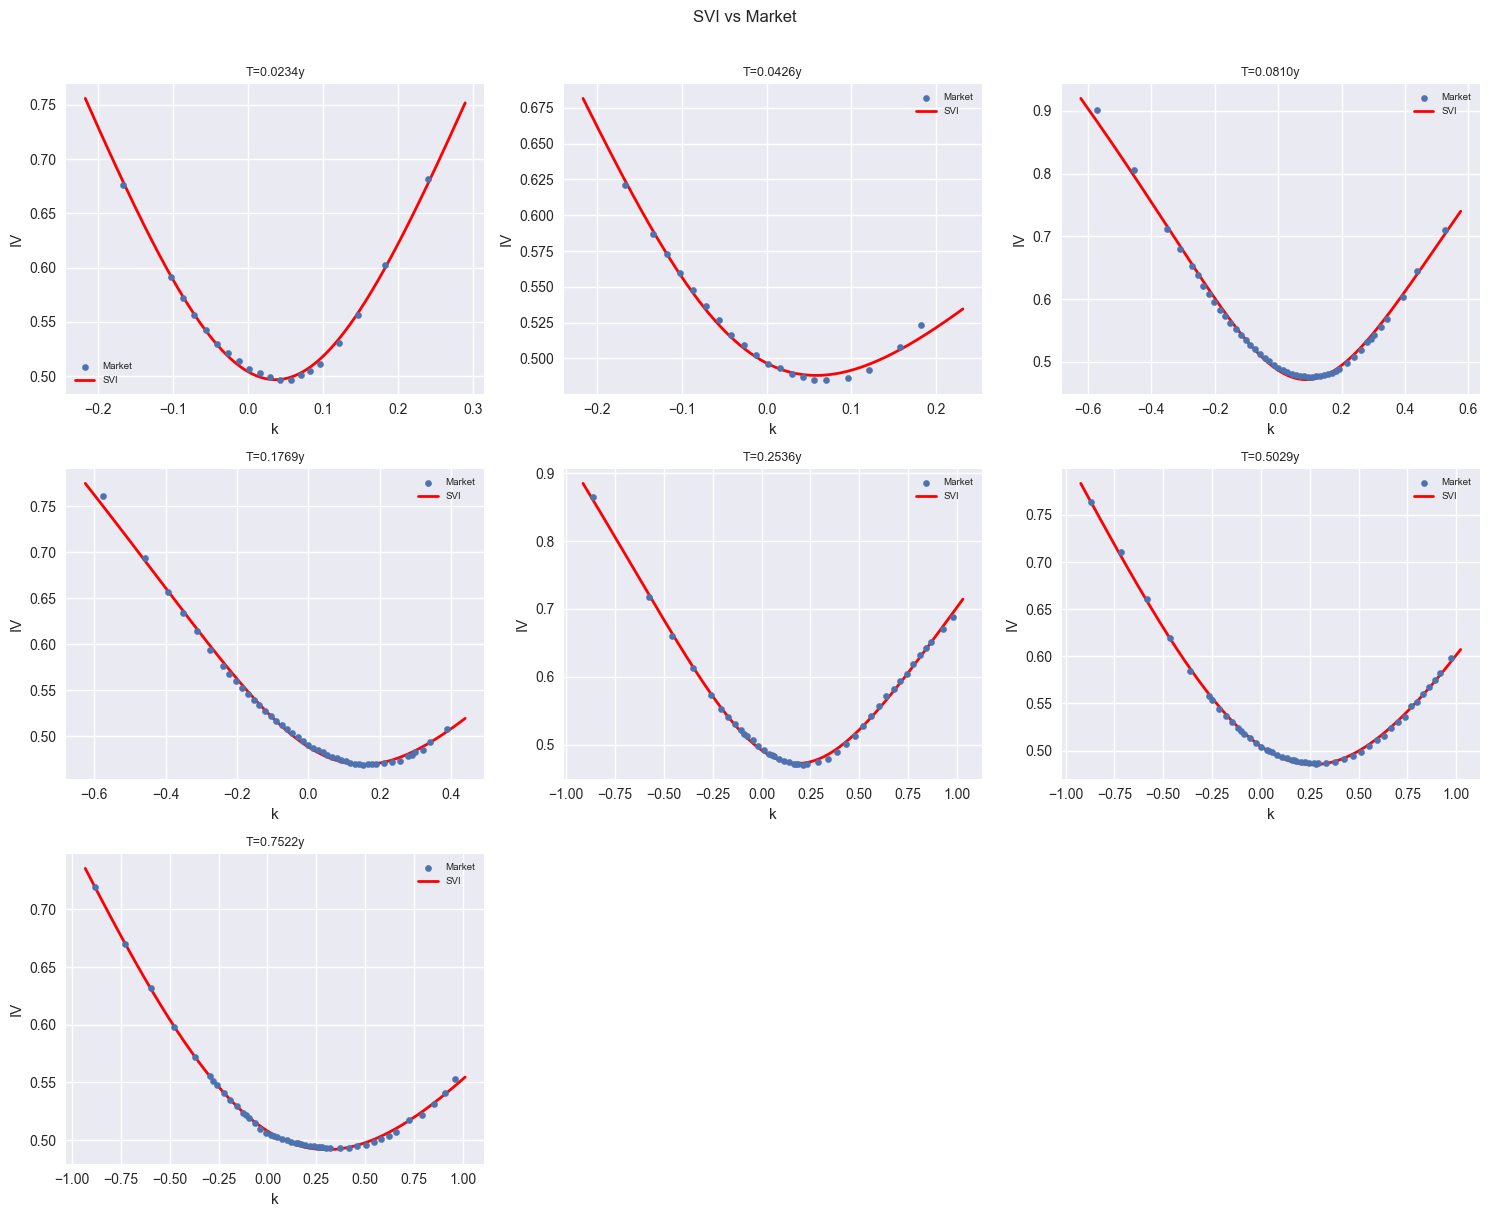

In [7]:
n = len(svi_params)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

for ax, (T_val, params) in zip(axes.flat, svi_params.items()):
    sl     = df[df["T"] == T_val].sort_values("k")
    kg     = np.linspace(sl["k"].min()-0.05, sl["k"].max()+0.05, 300)
    iv_fit = np.sqrt(np.maximum(svi(kg, *params), 0) / T_val)
    ax.scatter(sl["k"], sl["iv"], s=20, zorder=5, label="Market")
    ax.plot(kg, iv_fit, "r-", lw=2, label="SVI")
    ax.set_title(f"T={T_val:.4f}y", fontsize=9)
    ax.set_xlabel("k"); ax.set_ylabel("IV")
    ax.legend(fontsize=7)

for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.suptitle("SVI vs Market", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [8]:
# ── Arbitrage Checks ─────────────────────────────────────────────────────────
k_common = np.linspace(-0.8, 0.8, 400)
T_sorted = sorted(svi_params.keys())
w_matrix = np.array([svi(k_common, *svi_params[T]) for T in T_sorted])

# Calendar arbitrage: w(k, T) must be non-decreasing in T at every k
cal_violations = int(np.sum(np.diff(w_matrix, axis=0) < -1e-8))
print(f"Calendar arbitrage violations: {cal_violations}")

if cal_violations > 0:
    print("  -> Enforcing monotonicity via cummax across T...")
    w_matrix = np.maximum.accumulate(w_matrix, axis=0)
    print(f"  -> Violations after fix: {int(np.sum(np.diff(w_matrix, axis=0) < -1e-8))}")

# Butterfly arbitrage: d2w/dk2 >= 0 on each slice
dk = k_common[1] - k_common[0]
bfly = sum(int(np.sum(np.diff(row, 2) / dk**2 < -1e-6)) for row in w_matrix)
print(f"Butterfly violations (d²w/dk² < 0): {bfly}")


Calendar arbitrage violations: 127
  -> Enforcing monotonicity via cummax across T...
  -> Violations after fix: 0
Butterfly violations (d²w/dk² < 0): 0


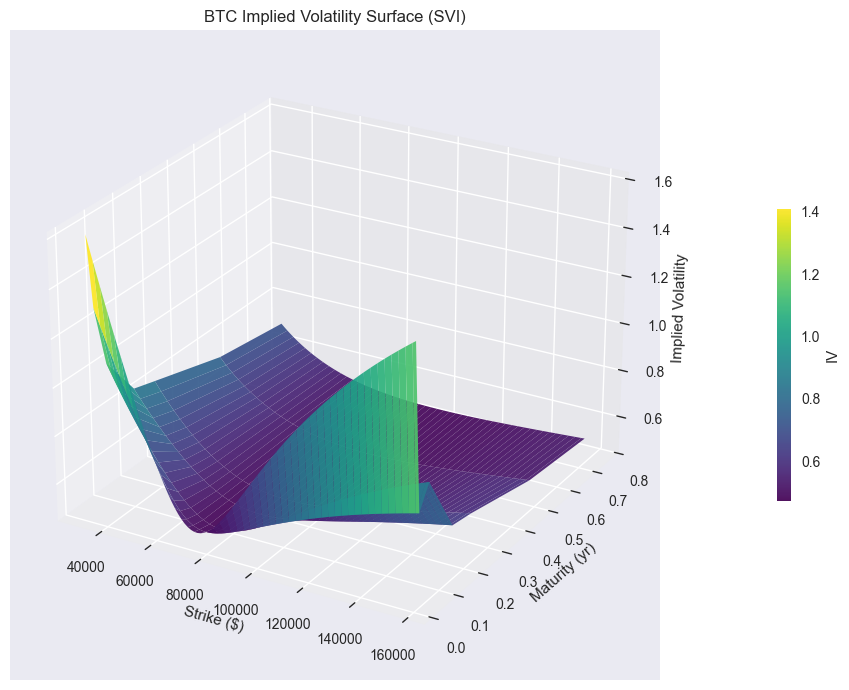

In [9]:
spot_val = float(df["spot"].iloc[0])
T_vals   = sorted(svi_params.keys())
K_range  = np.linspace(spot_val * np.exp(-0.8), spot_val * np.exp(0.8), 100)

K_mesh, T_mesh = np.meshgrid(K_range, T_vals)
IV_grid = np.full(K_mesh.shape, np.nan)

for i, T_val in enumerate(T_vals):
    F_val = forwards[T_val]
    k_row = np.log(K_range / F_val)
    w_row = svi(k_row, *svi_params[T_val])
    IV_grid[i, :] = np.sqrt(np.maximum(w_row, 0) / T_val)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(K_mesh, T_mesh, IV_grid, cmap="viridis",
                       alpha=0.92, linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.45, pad=0.1, label="IV")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Maturity (yr)")
ax.set_zlabel("Implied Volatility")
ax.view_init(elev=25, azim=-60)
plt.title("BTC Implied Volatility Surface (SVI)")
plt.tight_layout()
plt.show()


In [10]:
def bs_greeks(F, K, T, sigma, flag="call"):
    """
    Delta, Gamma, Vega, Theta for a European option.
    F  = implied forward (not spot)
    All values are per-contract (1 BTC).
    Theta is in vol-units per day (divide by 365 for calendar days).
    """
    sqrt_T = np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    pdf_d1 = norm.pdf(d1)

    if flag == "call":
        delta = norm.cdf(d1)
        theta = -(F * pdf_d1 * sigma) / (2 * sqrt_T)
    else:
        delta = norm.cdf(d1) - 1
        theta = -(F * pdf_d1 * sigma) / (2 * sqrt_T)

    gamma = pdf_d1 / (F * sigma * sqrt_T)
    vega  = F * pdf_d1 * sqrt_T          # per 1-unit move in sigma
    vega  = vega / 100                    # rebase: per 1 vol-point (0.01)
    theta = theta / 365                   # per calendar day

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta}


### Computing Greeks for All Options

We loop over every option in the filtered dataset, look up the SVI-implied vol at its specific $(k, T)$ point, then compute all four Greeks analytically.

This produces a `greeks_df` DataFrame — one row per option — that can be used for portfolio risk analysis.


In [11]:
# Compute Greeks for every option in df using SVI-implied vol
records = []

for _, row in df.iterrows():
    T_val  = row["T"]
    if T_val not in svi_params:
        continue
    F_val  = forwards[T_val]
    k_val  = np.log(row["strike"] / F_val)
    w_val  = svi(np.array([k_val]), *svi_params[T_val])[0]
    iv_svi = np.sqrt(max(w_val, 0) / T_val)
    if iv_svi < 0.01:
        continue
    g = bs_greeks(F_val, row["strike"], T_val, iv_svi, row["option_type"])
    records.append({
        "instrument_name": row["instrument_name"],
        "strike":          row["strike"],
        "option_type":     row["option_type"],
        "T":               T_val,
        "k":               k_val,
        "iv":              iv_svi,
        **g
    })

greeks_df = pd.DataFrame(records)
print(f"Greeks computed for {len(greeks_df)} options")
greeks_df.head(10)


Greeks computed for 273 options


,instrument_name,strike,option_type,T,k,iv,delta,gamma,vega,theta
0,BTC-3APR26-60000-P,60000.0,put,0.023441,-0.166281,0.679574,-0.049453,0.000014,11.090573,-44.044559
1,BTC-3APR26-64000-P,64000.0,put,0.023441,-0.101743,0.591461,-0.121238,0.000031,21.857984,-75.550510
2,BTC-3APR26-65000-P,65000.0,put,0.023441,-0.086239,0.573146,-0.152295,0.000038,25.550189,-85.577739
3,BTC-3APR26-66000-P,66000.0,put,0.023441,-0.070971,0.556567,-0.190658,0.000045,29.500570,-95.950971
4,BTC-3APR26-67000-P,67000.0,put,0.023441,-0.055933,0.541843,-0.237085,0.000053,33.499033,-106.073483
5,BTC-3APR26-68000-P,68000.0,put,0.023441,-0.041118,0.529080,-0.291809,0.000060,37.241639,-115.146623
6,BTC-3APR26-69000-P,69000.0,put,0.023441,-0.026519,0.518368,-0.354266,0.000066,40.356952,-122.252641
7,BTC-3APR26-70000-P,70000.0,put,0.023441,-0.012131,0.509777,-0.422912,0.000071,42.467232,-126.513055
8,BTC-3APR26-71000-C,71000.0,call,0.023441,0.002054,0.503345,0.504739,0.000073,43.274660,-127.291963
9,BTC-3APR26-72000-C,72000.0,call,0.023441,0.016040,0.499084,0.431832,0.000073,42.644376,-124.375915


In [ ]:
# Delta Surface
spot_val = float(df["spot"].iloc[0])
T_vals_g = sorted(svi_params.keys())
K_range  = np.linspace(spot_val * np.exp(-0.8), spot_val * np.exp(0.8), 100)

grids = {g: np.full((len(T_vals_g), len(K_range)), np.nan)
         for g in ["delta", "gamma", "vega", "theta"]}

for i, T_val in enumerate(T_vals_g):
    F_val = forwards[T_val]
    for j, K in enumerate(K_range):
        k_val  = np.log(K / F_val)
        w_val  = svi(np.array([k_val]), *svi_params[T_val])[0]
        iv_svi = np.sqrt(max(w_val, 0) / T_val)
        if iv_svi < 0.01:
            continue
        flag = "call" if K >= F_val else "put"
        g = bs_greeks(F_val, K, T_val, iv_svi, flag)
        for key in grids:
            grids[key][i, j] = g[key]

K_mesh_g, T_mesh_g = np.meshgrid(K_range, T_vals_g)


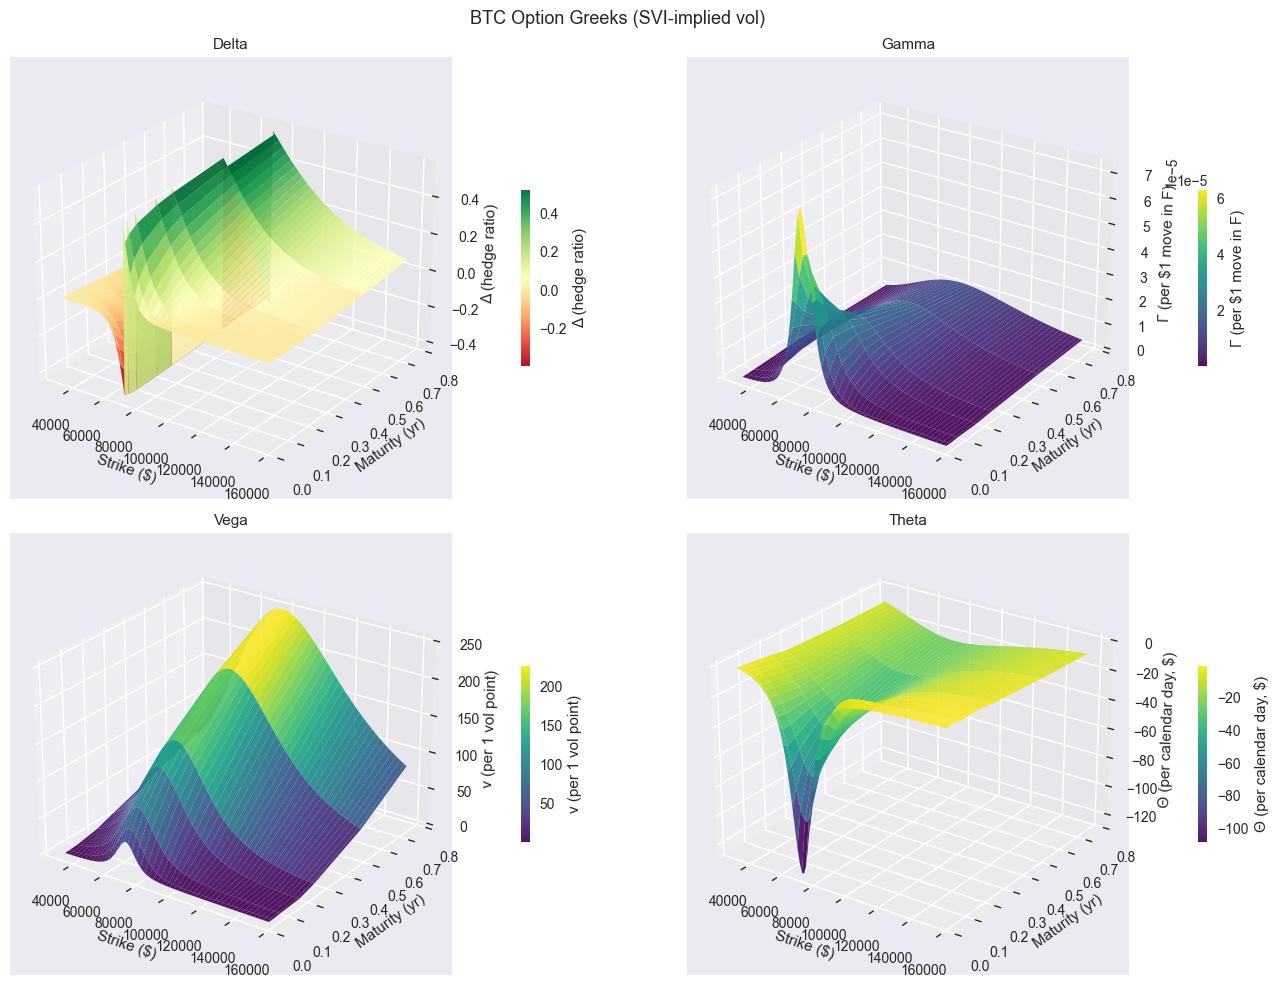

In [ ]:
# Greeks Surfaces
greek_labels = {
    "delta": ("Delta",  "Δ (hedge ratio)"),
    "gamma": ("Gamma",  "Γ (per $1 move in F)"),
    "vega":  ("Vega",   "ν (per 1 vol point)"),
    "theta": ("Theta",  "Θ (per calendar day, $)"),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          subplot_kw={"projection": "3d"})

for ax, (key, (title, zlabel)) in zip(axes.flat, greek_labels.items()):
    surf = ax.plot_surface(K_mesh_g, T_mesh_g, grids[key],
                           cmap="RdYlGn" if key == "delta" else "viridis",
                           alpha=0.92, linewidth=0, antialiased=True)
    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1, label=zlabel)
    ax.set_xlabel("Strike ($)")
    ax.set_ylabel("Maturity (yr)")
    ax.set_zlabel(zlabel)
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=25, azim=-55)

plt.suptitle("BTC Option Greeks (SVI-implied vol)", fontsize=13)
plt.tight_layout()
plt.show()


### ATM Greeks Term Structure

The ATM term structure isolates how each Greek behaves at $k=0$ as maturity varies. The theoretical scaling laws are:

| Greek | Scales with $T$ |
|-------|-----------------|
| Delta (call) | $\nearrow$ slowly (approaches 0.5 from below as $T \to 0)|
| Gamma | $\propto 1/\sqrt{T}$ - diverges as $T \to 0$ |
| Vega | $\propto \sqrt{T}$ - grows with maturity |
| Theta | $\propto 1/\sqrt{T}$ - largest for short dates |



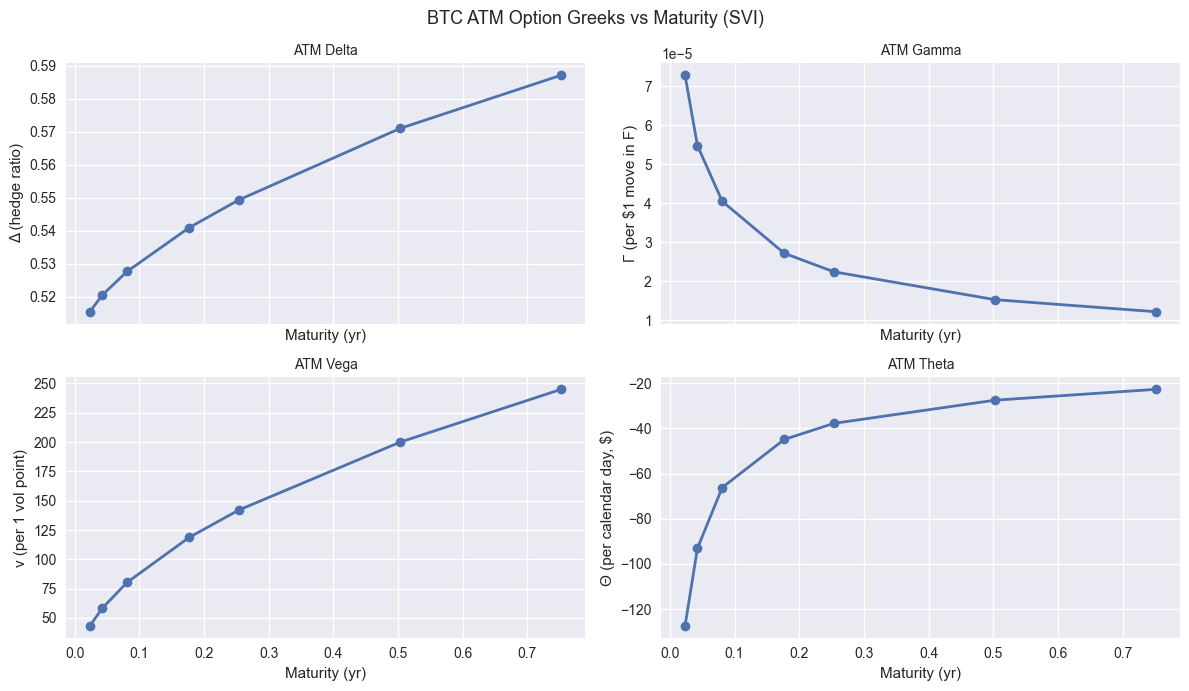

In [ ]:
# ATM Greeks term structure 
atm_greeks = {g: [] for g in ["delta", "gamma", "vega", "theta"]}

for T_val in T_vals_g:
    F_val  = forwards[T_val]
    w_atm  = svi(np.array([0.0]), *svi_params[T_val])[0]
    iv_atm = np.sqrt(max(w_atm, 0) / T_val)
    g = bs_greeks(F_val, F_val, T_val, iv_atm, "call")   # ATM call
    for key in atm_greeks:
        atm_greeks[key].append(g[key])

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

for ax, (key, (title, ylabel)) in zip(axes.flat, greek_labels.items()):
    ax.plot(T_vals_g, atm_greeks[key], marker="o", lw=2)
    ax.set_title(f"ATM {title}", fontsize=10)
    ax.set_xlabel("Maturity (yr)")
    ax.set_ylabel(ylabel)

plt.suptitle("BTC ATM Option Greeks vs Maturity (SVI)", fontsize=13)
plt.tight_layout()
plt.show()
